In [1]:
import pandas as pd
import matplotlib.pyplot as plt # visualizing data
import seaborn as sns

In [2]:
df = pd.read_csv("shopping_trends_updated.csv")

In [14]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
776,777,49,Male,Shirt,Clothing,60,Alabama,M,Maroon,Spring,5.0,Yes,Standard,Yes,Yes,8,Venmo,Every 3 Months
1664,1665,19,Male,Handbag,Accessories,53,Minnesota,M,Purple,Spring,5.0,No,Next Day Air,Yes,Yes,35,PayPal,Weekly
1277,1278,19,Male,Blouse,Clothing,97,Rhode Island,L,Green,Spring,5.0,No,Express,Yes,Yes,5,Venmo,Quarterly
2632,2633,24,Male,Scarf,Accessories,27,Alaska,M,Black,Fall,5.0,No,Next Day Air,No,No,14,Cash,Annually
965,966,43,Male,Boots,Footwear,55,Delaware,L,Black,Spring,5.0,Yes,Store Pickup,Yes,Yes,10,Credit Card,Annually


In [4]:
# Summaries for the numerical columns...
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [ ]:
# Find any null value.

df.isna().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [6]:
# Find the duplicat values in the dataframes...
df.duplicated().sum()

0

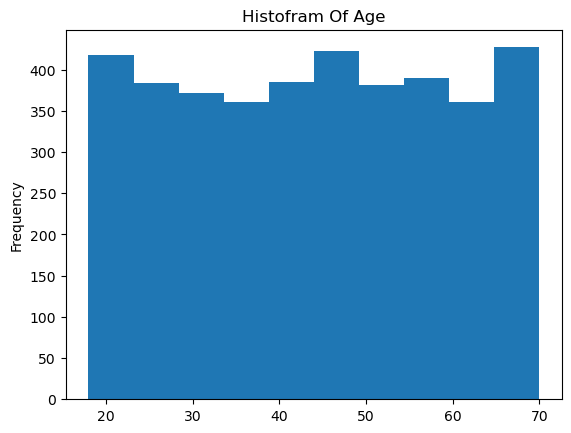

In [7]:
# Create a histogram of age..
df["Age"].plot(kind="hist")
plt.title("Histofram Of Age")
plt.show()

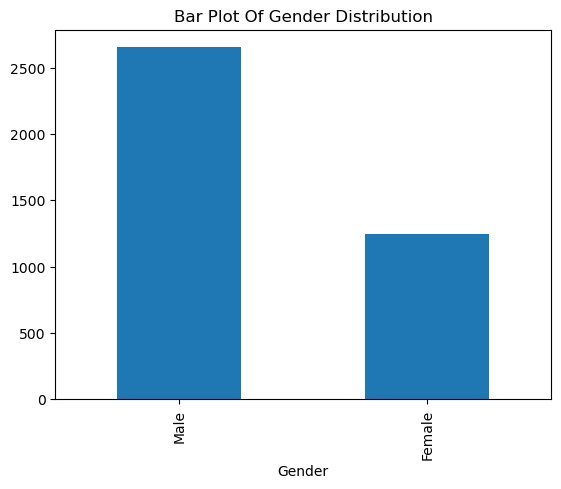

In [8]:
# Creating a bar for the distribution of gender...
df["Gender"].value_counts().plot(kind="bar")
plt.title("Bar Plot Of Gender Distribution")
plt.show()

In [10]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [12]:
# Group by category and calculate the mean value of the purchase amount...

df.groupby("Category")["Purchase Amount (USD)"].mean().sort_values(ascending=False).round(2)

Category
Footwear       60.26
Clothing       60.03
Accessories    59.84
Outerwear      57.17
Name: Purchase Amount (USD), dtype: float64

In [13]:
# To Sort The Data With help of using the raing value...
df.sort_values("Review Rating", ascending=False, inplace=True)

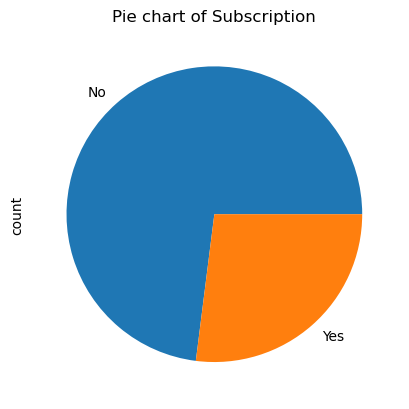

In [15]:
# Create a pie chart for the Subscription Status...
df['Subscription Status'].value_counts().plot(kind='pie')
plt.title("Pie chart of Subscription")
plt.show()

<Axes: ylabel='count'>

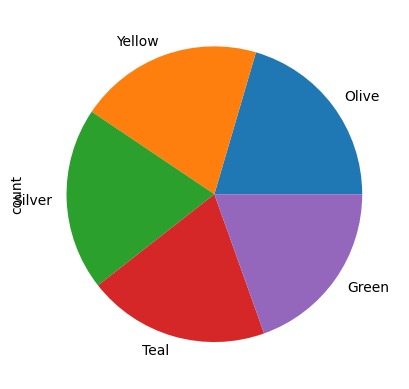

In [17]:
# Find what type of colour are used in the shopping Trends...
df['Color'].value_counts().head(5).plot(kind='pie')

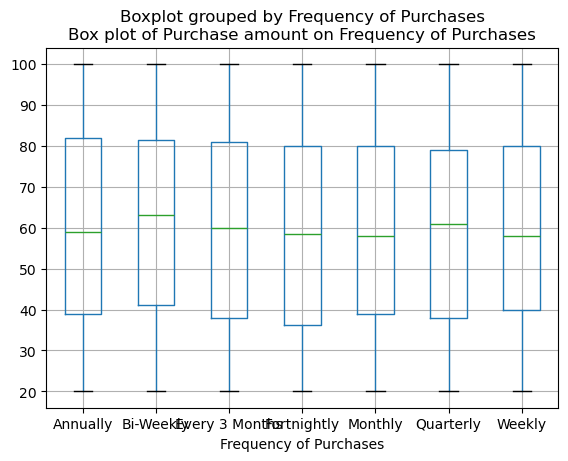

In [18]:
# Creating a boxplot for the column of purchase with the frequency of purchases...
df.boxplot(column="Purchase Amount (USD)", by = "Frequency of Purchases")
plt.title("Box plot of Purchase amount on Frequency of Purchases")
plt.show()

In [24]:
# count the values of Payment Method
df["Payment Method"].value_counts().sort_values(ascending=False).head(2)

Payment Method
PayPal         677
Credit Card    671
Name: count, dtype: int64

In [39]:
# Create pivot table using Purchase Amount (USD),Location, Item Purchased and thire mean value...

pd.pivot_table(df, values = "Purchase Amount (USD)", index="Location", columns="Item Purchased", aggfunc="mean").head(5)

Item Purchased,Backpack,Belt,Blouse,Boots,Coat,Dress,Gloves,Handbag,Hat,Hoodie,...,Scarf,Shirt,Shoes,Shorts,Skirt,Sneakers,Socks,Sunglasses,Sweater,T-shirt
Location,,,,,,,,,,,,,,,,,,,,,
Alabama,74.0,26.500000,52.0,73.666667,54.500000,55.200000,85.000000,57.666667,76.000000,53.000000,...,75.333333,48.2,54.333333,49.000000,68.666667,79.500000,93.50,62.666667,40.500000,52.50
Alaska,74.6,76.750000,67.5,56.000000,45.500000,74.500000,66.333333,46.000000,52.666667,56.500000,...,45.000000,59.5,80.000000,76.666667,87.333333,73.333333,74.25,83.000000,50.333333,56.75
Arizona,48.6,84.500000,61.0,NaN,65.333333,71.000000,87.000000,58.666667,87.000000,66.666667,...,53.500000,80.0,87.000000,46.000000,68.500000,78.500000,61.00,66.000000,70.400000,62.00
Arkansas,90.0,55.000000,66.0,50.000000,54.250000,62.800000,64.333333,50.000000,35.000000,55.250000,...,67.500000,59.0,59.500000,95.000000,44.500000,69.000000,60.50,56.000000,71.500000,52.00
California,57.4,61.666667,39.5,62.500000,55.000000,58.428571,53.000000,65.250000,49.000000,56.000000,...,54.500000,42.8,NaN,63.333333,56.000000,73.000000,83.00,69.400000,42.000000,69.00


In [40]:
# Find mean of Purchase Amount by thier size...
df.groupby("Size")["Purchase Amount (USD)"].mean()

Size
L     58.563153
M     59.924217
S     61.037707
XL    60.090909
Name: Purchase Amount (USD), dtype: float64

In [41]:
# Find the sum value of both paymentss method and puchase amount...
df.groupby("Payment Method")["Purchase Amount (USD)"].sum()

Payment Method
Bank Transfer    36544
Cash             40002
Credit Card      40310
Debit Card       38742
PayPal           40109
Venmo            37374
Name: Purchase Amount (USD), dtype: int64

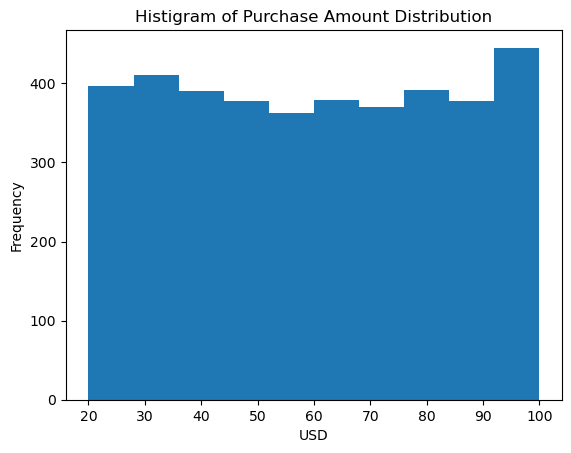

In [42]:
# Create a Histigram of Purchase Amount Distribution... 

df["Purchase Amount (USD)"].plot(kind="hist", bins= 10)
plt.xlabel('USD')
plt.ylabel('Frequency')
plt.title("Histigram of Purchase Amount Distribution")
plt.show()

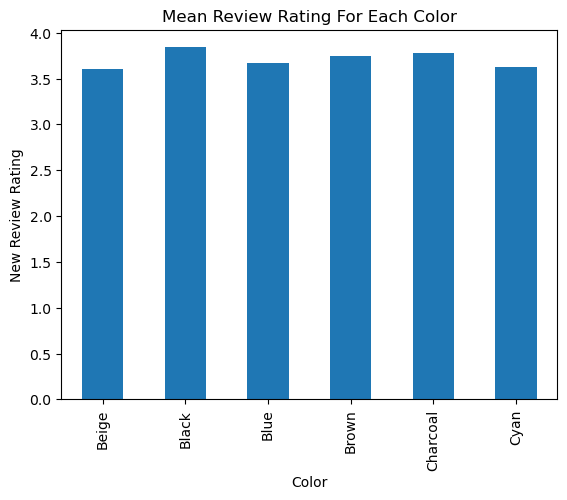

In [44]:
# Creat bar plot using the Mean Review Rating For Each Color
df.groupby("Color")["Review Rating"].mean().head(6).plot(kind="bar")
plt.xlabel('Color')
plt.ylabel('New Review Rating')
plt.title("Mean Review Rating For Each Color")
plt.show()

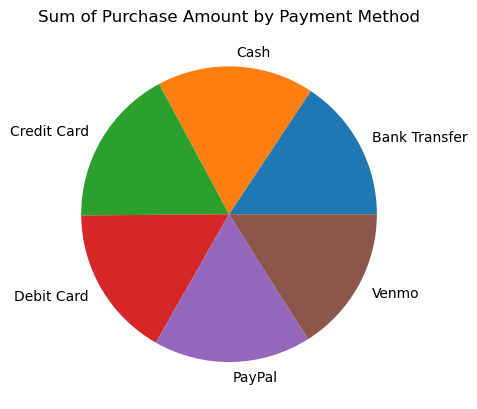

In [45]:
# Creat pic chat using group by function of Purchase Amount and Payment Method to find the sum...

df.groupby("Payment Method")["Purchase Amount (USD)"].sum().plot(kind="pie")
plt.ylabel("")
plt.title("Sum of Purchase Amount by Payment Method")
plt.show()

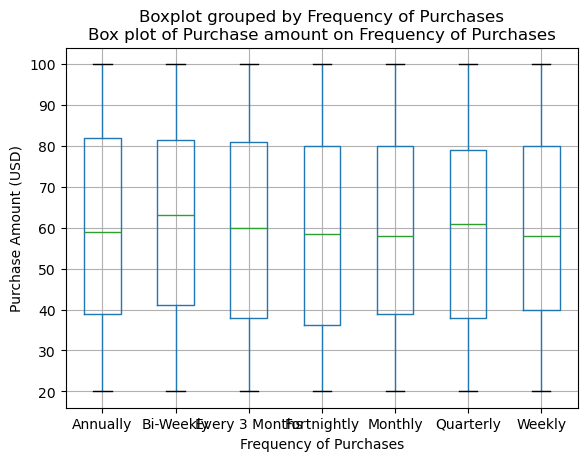

In [ ]:
# Creating a boxplot for the column of purchase with the frequency of purchases...
df.boxplot(column="Purchase Amount (USD)", by = "Frequency of Purchases")
plt.xlabel("Frequency of Purchases")
plt.ylabel("Purchase Amount (USD)")
plt.title("Box plot of Purchase amount on Frequency of Purchases")
plt.show()

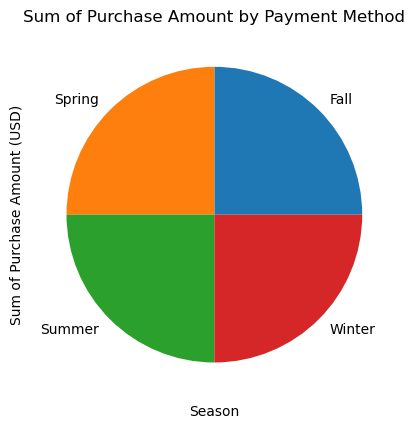

In [49]:
# Creat pic chat using group by function with Season and Payment Method to find the max...

df.groupby("Season")["Purchase Amount (USD)"].max().plot(kind="pie")
plt.xlabel("Season")
plt.ylabel("Sum of Purchase Amount (USD)")
plt.title("Sum of Purchase Amount by Payment Method")
plt.show()